# Jev step rankings

`score-jev.js` records *whether* each navigation step was right. `rank-jev.js` records
*how* right: where the correct member sat in Jev's probability distribution, how much
mass it got, what won instead, and how peaked the distribution was.

This notebook reads `results/steps/*.csv`. It is entirely separate from `results.ipynb`,
which reads `results/*.csv` — the two never touch the same files.

Four questions:

1. **Top-k** — if the editor reordered the menu instead of picking one member, how often
   would the right answer be near the top?
2. **Calibration** — when Jev says 0.7, is it right 70% of the time? Everything else here
   depends on the answer.
3. **Auto-advance** — if the editor only auto-selected above a confidence threshold, what
   coverage and what accuracy would it get?
4. **Confusability** — which member names does it mix up? That is a finding about The
   Gamma's naming, not about the model.


In [14]:
import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

steps_dir = os.path.join('results', 'steps')

frames = []
for path in sorted(glob.glob(os.path.join(steps_dir, '*.csv'))):
    m = re.match(r'^(.+?)__(.+?)__(.+?)__\d+\.csv$', os.path.basename(path))
    if not m:
        continue
    df = pd.read_csv(path)
    if df.empty:
        continue
    df['model'], df['prompt'] = m.group(1), m.group(2)
    frames.append(df)

if not frames:
    raise SystemExit(f'No ranking CSVs in {steps_dir}/ - run: node rank-jev.js -n 61 -o results')

data = pd.concat(frames, ignore_index=True)

# Forced moves (single-option menus) make no API call and carry no distribution.
ranked = data[data['api_called'] == 1].copy()

# A rank only means something when nothing shares the truth's probability. The
# distributions are sparse, so a member sitting among 131 options all at exactly 0.0
# would otherwise report a confident-looking 'rank 15'.
clean = ranked[ranked['truth_tied'] == 1].copy()

dropped = len(ranked) - len(clean)
print(f'{len(data)} steps, {len(ranked)} ranked, {len(clean)} untied')
print(f'{dropped} rows dropped from rank metrics as tied ({100 * dropped / max(len(ranked), 1):.1f}%)')
data.head()


1330 steps, 1314 ranked, 1162 untied
152 rows dropped from rank metrics as tied (11.6%)


,snippet_id,chain_index,step_index,provider,step,n_options,n_members,api_called,correct,truth_rank,...,top1_name,top1_prob,top2_name,top2_prob,confidence,entropy_bits,input_tokens,output_tokens,model,prompt
0,23,0,0,olympics,filter data,9,9,1,1,1.0,...,filter data,0.40,get series,0.37,0.32,1.6065,1265,91,typesafe-jev-1.13,default-prompt
1,23,0,1,olympics,Games is,37,37,1,0,2.0,...,Medal is,0.38,Games is,0.31,0.35,2.4772,1511,362,typesafe-jev-1.13,default-prompt
2,23,0,2,olympics,Rio (2016),29,29,1,1,1.0,...,Rio (2016),0.99,London (2012),0.01,0.99,0.0808,1578,392,typesafe-jev-1.13,default-prompt
3,23,0,3,olympics,then,74,74,1,1,1.0,...,then,0.84,and Medal is,0.12,0.83,0.8241,1879,750,typesafe-jev-1.13,default-prompt
4,23,0,4,olympics,group data,9,9,1,1,1.0,...,group data,0.80,get series,0.17,0.78,0.8714,1288,91,typesafe-jev-1.13,default-prompt


## Top-k accuracy

`top1` follows the actual choice rather than the rank: on an exact tie the correct member
can rank 1 while the argmax lands on the option it is tied with. `top3`, `top5` and MRR
use the rank, so they are computed on untied rows only.


In [15]:
def topk(df):
    if df.empty:
        return pd.Series(dtype=float)
    return pd.Series({
        'steps': len(df),
        'top1': df['correct'].mean(),
        'top3': (df['truth_rank'] <= 3).mean(),
        'top5': (df['truth_rank'] <= 5).mean(),
        'mrr': (1 / df['truth_rank']).mean(),
        'median_options': df['n_options'].median(),
    })


FMT = {'top1': '{:.1%}', 'top3': '{:.1%}', 'top5': '{:.1%}',
       'mrr': '{:.3f}', 'steps': '{:.0f}', 'median_options': '{:.0f}'}

overall = clean.groupby(['model', 'prompt']).apply(topk)
display(overall.style.format(FMT))

by_provider = clean.groupby(['prompt', 'provider']).apply(topk)
display(by_provider.style.format(FMT))


C:\Users\tomas\AppData\Local\Temp\ipykernel_24580\2977899053.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall = clean.groupby(['model', 'prompt']).apply(topk)


C:\Users\tomas\AppData\Local\Temp\ipykernel_24580\2977899053.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_provider = clean.groupby(['prompt', 'provider']).apply(topk)


### The gap between top-1 and top-5

This is the practical point. The scorer marks a step wrong unless the single best guess
matches, but The Gamma's editor shows a *menu* — it never has to commit to one member.
The distance between the bars is accuracy available for free by reordering the completion
list rather than replacing it.


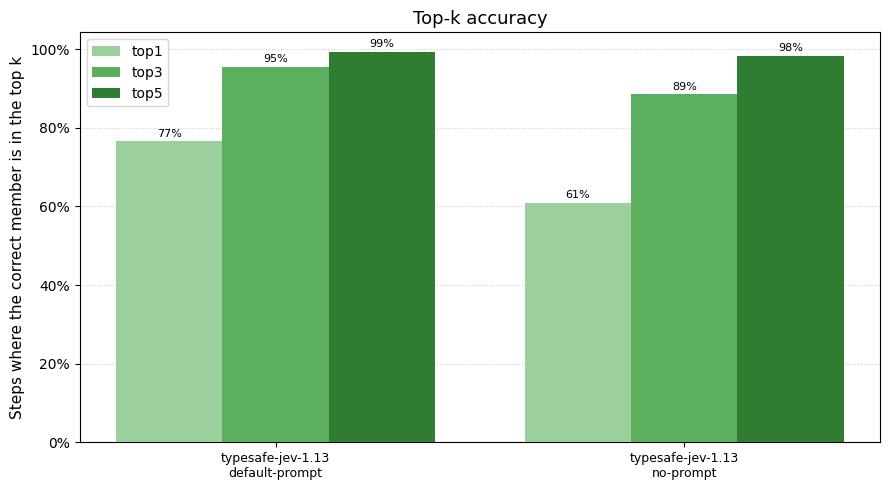

In [16]:
if clean.empty:
    print('No untied rows.')
else:
    cfgs = sorted(clean.groupby(['model', 'prompt']).groups.keys())
    fig, ax = plt.subplots(figsize=(9, 5))
    width = 0.26
    x = np.arange(len(cfgs))
    for i, (k, colour) in enumerate(zip(['top1', 'top3', 'top5'],
                                        ['#9BCF9B', '#5CAF5C', '#2E7D32'])):
        vals = [topk(clean[(clean['model'] == m) & (clean['prompt'] == p)])[k] * 100
                for m, p in cfgs]
        bars = ax.bar(x + (i - 1) * width, vals, width, label=k, color=colour, zorder=3)
        ax.bar_label(bars, fmt='%.0f%%', fontsize=8, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels([m + '\n' + p for m, p in cfgs], fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylabel('Steps where the correct member is in the top k', fontsize=11)
    ax.set_title('Top-k accuracy', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle=':', alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig('results/topk.png', dpi=150)
    plt.show()


## Calibration

TypeSafe trains for calibrated probabilities, so `top1_prob = 0.7` should mean the top
choice is right about 70% of the time. That claim has never been tested on type-provider
navigation. If it holds here the confidence thresholds below can be trusted as they are;
if it does not, they need fitting first.

Points below the diagonal mean overconfidence. Bucket sizes are annotated, because a
bucket with a handful of steps in it is not evidence of anything.


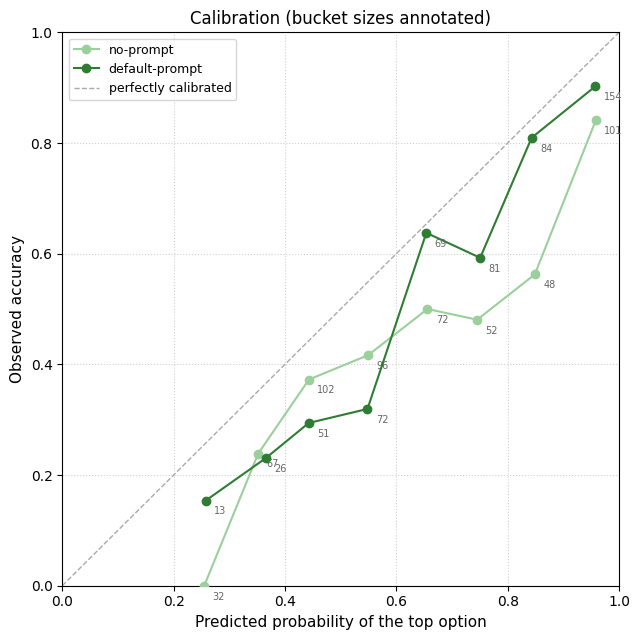

In [9]:
if ranked.empty:
    print('No ranked rows.')
else:
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    bins = np.linspace(0, 1, 11)

    for prompt, colour in [('no-prompt', '#9BCF9B'), ('default-prompt', '#2E7D32')]:
        sub = ranked[ranked['prompt'] == prompt]
        if sub.empty:
            continue
        idx = np.digitize(sub['top1_prob'], bins) - 1
        xs, ys, ns = [], [], []
        for b in range(len(bins) - 1):
            sel = sub[idx == b]
            if len(sel) < 5:
                continue
            xs.append(sel['top1_prob'].mean())
            ys.append(sel['correct'].mean())
            ns.append(len(sel))
        ax.plot(xs, ys, 'o-', color=colour, label=prompt, zorder=3)
        for xi, yi, n in zip(xs, ys, ns):
            ax.annotate(str(n), (xi, yi), textcoords='offset points',
                        xytext=(6, -10), fontsize=7, color='#666')

    ax.plot([0, 1], [0, 1], '--', color='#aaa', linewidth=1, zorder=2,
            label='perfectly calibrated')
    ax.set_xlabel('Predicted probability of the top option', fontsize=11)
    ax.set_ylabel('Observed accuracy', fontsize=11)
    ax.set_title('Calibration (bucket sizes annotated)', fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(linestyle=':', alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig('results/calibration.png', dpi=150)
    plt.show()


## Confidence-gated auto-advance

The editor does not have to choose between 'always guess' and 'never guess'. It can
auto-select when Jev is confident and fall back to the plain menu when it is not.

Sweeping the threshold gives the trade: how many steps get taken automatically, and how
often that is right. A usable operating point has the green line high enough that a wrong
auto-advance is rare, while the grey line still covers a worthwhile share of steps.


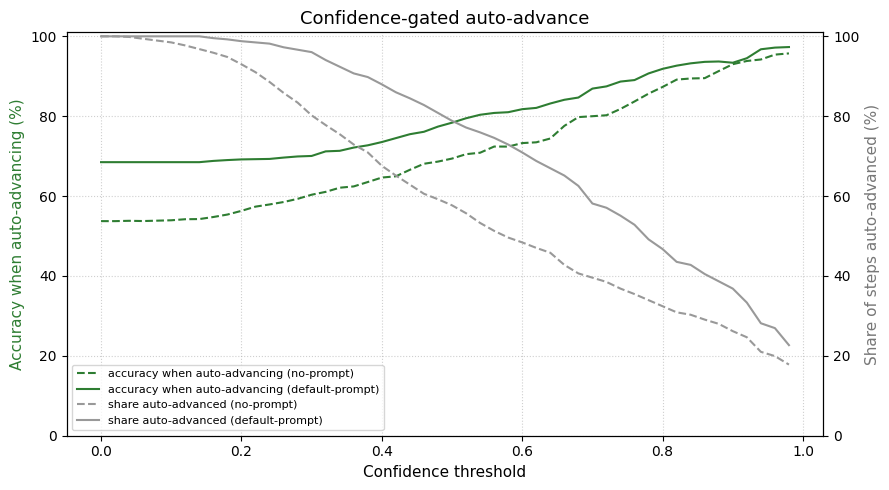

Operating points (default-prompt):


threshold,auto_advanced,accuracy_when_auto,accuracy_when_deferred
0.30,96.0%,70.0%,30.8%
0.50,78.8%,78.4%,31.7%
0.70,59.1%,86.3%,42.8%
0.80,46.7%,91.9%,48.0%
0.90,36.8%,93.4%,54.0%
0.95,28.2%,96.8%,57.4%


In [10]:
if ranked.empty:
    print('No ranked rows.')
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax2 = ax.twinx()
    thresholds = np.linspace(0, 0.98, 50)

    for prompt, style in [('no-prompt', '--'), ('default-prompt', '-')]:
        sub = ranked[ranked['prompt'] == prompt]
        if sub.empty:
            continue
        cov = [(sub['confidence'] >= t).mean() * 100 for t in thresholds]
        acc = [sub[sub['confidence'] >= t]['correct'].mean() * 100
               if (sub['confidence'] >= t).any() else np.nan for t in thresholds]
        ax.plot(thresholds, acc, style, color='#2E7D32', zorder=3,
                label='accuracy when auto-advancing (' + prompt + ')')
        ax2.plot(thresholds, cov, style, color='#999', zorder=3,
                 label='share auto-advanced (' + prompt + ')')

    ax.set_xlabel('Confidence threshold', fontsize=11)
    ax.set_ylabel('Accuracy when auto-advancing (%)', fontsize=11, color='#2E7D32')
    ax2.set_ylabel('Share of steps auto-advanced (%)', fontsize=11, color='#777')
    ax.set_ylim(0, 101)
    ax2.set_ylim(0, 101)
    ax.set_title('Confidence-gated auto-advance', fontsize=13)
    lines = ax.get_lines() + ax2.get_lines()
    ax.legend(lines, [l.get_label() for l in lines], fontsize=8, loc='lower left')
    ax.grid(linestyle=':', alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig('results/auto_advance.png', dpi=150)
    plt.show()

    sub = ranked[ranked['prompt'] == 'default-prompt']
    if not sub.empty:
        rows = []
        for t in [0.3, 0.5, 0.7, 0.8, 0.9, 0.95]:
            sel = sub[sub['confidence'] >= t]
            rest = sub[sub['confidence'] < t]
            rows.append({
                'threshold': t,
                'auto_advanced': len(sel) / len(sub),
                'accuracy_when_auto': sel['correct'].mean() if len(sel) else np.nan,
                'accuracy_when_deferred': rest['correct'].mean() if len(rest) else np.nan,
            })
        print('Operating points (default-prompt):')
        display(pd.DataFrame(rows).style.format({
            'threshold': '{:.2f}', 'auto_advanced': '{:.1%}',
            'accuracy_when_auto': '{:.1%}',
            'accuracy_when_deferred': '{:.1%}'}).hide(axis='index'))


## Confusability

Where the model went wrong, what did it pick instead? A pair that recurs across snippets
is evidence that two member names read as interchangeable — a property of The Gamma's API
surface rather than of the model, and something a rename could fix.

The second table ranks menus by entropy: high mean entropy at a given member means the
options at that point are genuinely hard to tell apart.


In [11]:
wrong = ranked[ranked['correct'] == 0]
if wrong.empty:
    print('Nothing wrong — suspicious.')
else:
    pairs = (wrong.groupby(['step', 'top1_name'])
             .agg(times=('step', 'size'), mean_truth_prob=('truth_prob', 'mean'))
             .sort_values('times', ascending=False).head(20))
    print('Most frequent confusions (correct member -> what won instead):')
    display(pairs.style.format({'mean_truth_prob': '{:.3f}'}))

    ambiguity = (ranked.groupby('step')
                 .agg(times=('step', 'size'), mean_entropy=('entropy_bits', 'mean'),
                      accuracy=('correct', 'mean'), mean_options=('n_options', 'mean'))
                 .query('times >= 4')
                 .sort_values('mean_entropy', ascending=False).head(15))
    print()
    print('Menus with the most spread-out distributions (>= 4 occurrences):')
    display(ambiguity.style.format({'mean_entropy': '{:.2f}', 'accuracy': '{:.1%}',
                                    'mean_options': '{:.0f}'}))


Most frequent confusions (correct member -> what won instead):


,,times,mean_truth_prob
step,top1_name,,
then,preview,38,0.191
get series,get the data,28,0.105
group data,get the data,19,0.139
filter data,get the data,16,0.105
Climate Change,Environment,13,0.374
paging,get the data,11,0.121
group data,get series,11,0.183
by date,by tag,10,0.341
sort data,get series,9,0.060



Menus with the most spread-out distributions (>= 4 occurrences):


,times,mean_entropy,accuracy,mean_options
step,,,,
2015,4,3.53,25.0%,17
map(fun x -> x / 1000),4,3.28,0.0%,26
reverse(),4,3.21,0.0%,26
"setProperties(seriesName=""Denmark"")",4,3.11,0.0%,26
"setProperties(seriesName=""France"")",4,3.05,0.0%,26
"setProperties(seriesName=""United Kingdom"")",4,2.90,0.0%,26
middle Year,4,2.75,0.0%,12
Role is not,4,2.24,0.0%,7
Team is,4,2.16,25.0%,37
